# Project Name - Titanic Survival Predication

In [2]:
# import library
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
# load the dataset
test = pd.read_csv("D:/Project/Titanic-Prediction/data/test.csv")
train = pd.read_csv("D:/Project/Titanic-Prediction/data/train.csv")

In [4]:
# first 5 data
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# present columns
train.columns 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
# shape of data
row, columns = train.shape
print(f" Row:{row}\n Columns:{columns}")

 Row:891
 Columns:12


In [7]:
# info 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# check null values
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation
- As we can see out of 891 [Age, Cabin, Embarked] misses the data 
- Cabin misses out 687 out of 891
- Embarked misses with 2 data 

In [9]:
# Duplicate values
train.duplicated().sum(0)

np.int64(0)

In [10]:
# Detaile info of data
train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

# EDA

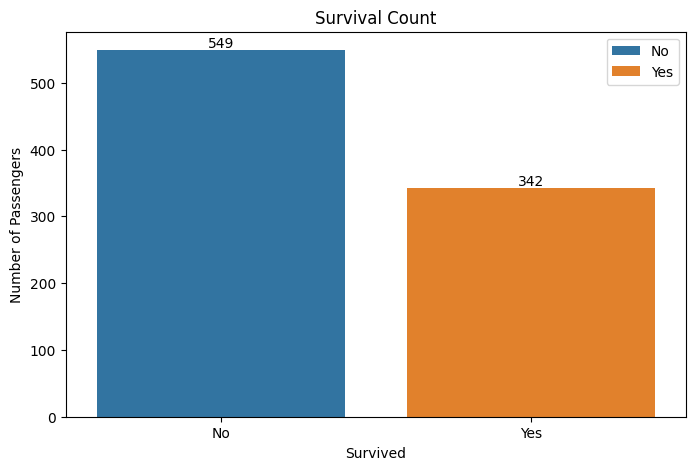

In [11]:
# Survival Count

plt.figure(figsize=(8,5))
ax = sns.countplot(data=train,x=train['Survived'],hue='Survived')

plt.title('Survival Count')
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.ylabel('Number of Passengers')

for container in ax.containers:
    ax.bar_label(container)

plt.legend(
    labels = ["No","Yes"]
    )
plt.show()

### Observation
- Most passengers aboard the Titanic did not survive the disaster.

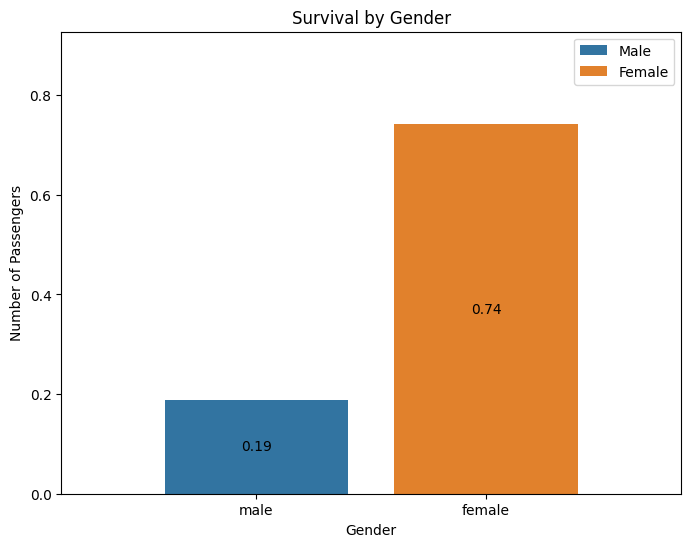

In [12]:
# Survival by gender

plt.figure(figsize=(8,6))
ax = sns.barplot(data=train,x=train['Sex'],y=train['Survived'],hue='Sex',errorbar=None)
ax.bar_label(ax.containers[0],fmt="%.2f",label_type='center')
ax.bar_label(ax.containers[1],fmt="%.2f",label_type='center')
plt.legend(
    labels = ['Male','Female']
)
ax.margins(0.25)
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

### Observation
- Gender had a strong influence on survival. 
- Female passengers had a much higher chance of survival than male passengers, reflecting the "women and children first" evacuation policy.
 

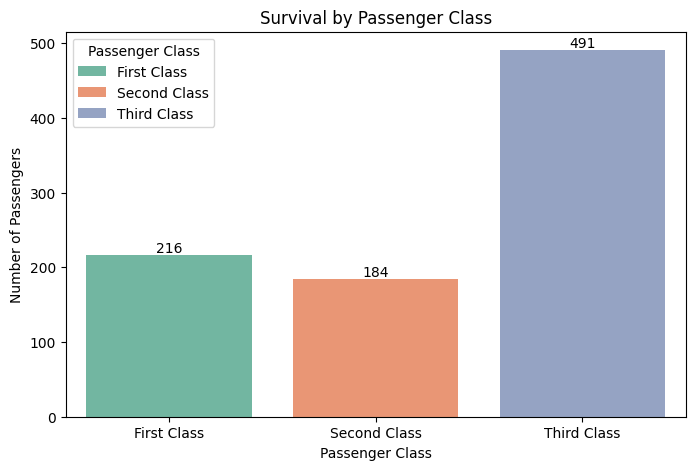

In [13]:
# Survival by Passenger class

plt.figure(figsize=(8,5))

ax = sns.countplot(x=train['Pclass'],hue=train['Pclass'],palette='Set2')

for container in ax.containers:
    ax.bar_label(container,label_type='edge')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0,1,2],labels=['First Class','Second Class','Third Class'])
plt.legend(
    title = 'Passenger Class',
    labels = ['First Class','Second Class','Third Class']
)
plt.show()

### Observation 
- Passengers traveling in First Class had the highest survival rate, while Third Class passengers had the lowest, indicating that passenger class significantly affected survival.

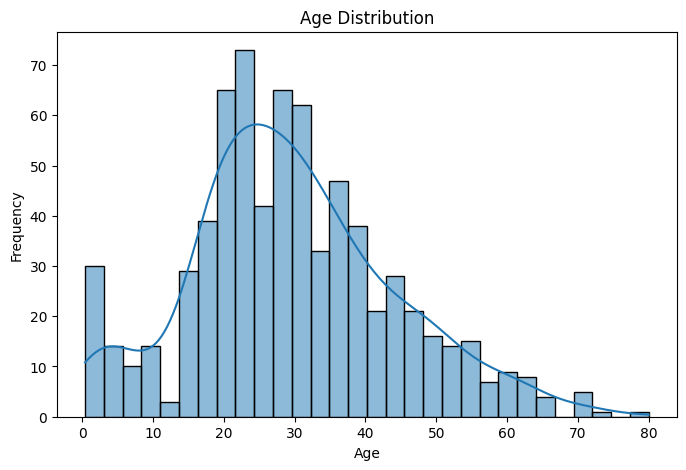

In [14]:
# Age distribution

plt.figure(figsize=(8,5))
sns.histplot(train['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Observation
- As we observe data is little right-skewed.
- The majority of passengers were young adults. 
- The presence of missing age values indicates that data preprocessing is necessary before model training.

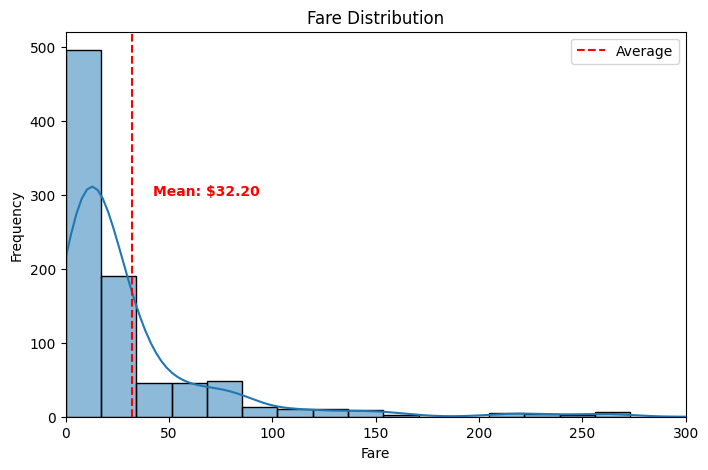

In [27]:
# Fare distribution

plt.figure(figsize=(8,5))
sns.histplot(train['Fare'], bins=30, kde=True)
average = train['Fare'].mean()

plt.axvline(
    x=average,
    color = 'red',
    linestyle = '--',
    label = 'Average'
)

plt.text(
    x=average + 10,                  # Slightly to the right of the line
    y=300,                           # Vertical position on the y-axis
    s=f'Mean: ${average:.2f}',      # The text string to display
    color='red',
    fontweight='bold'
)

plt.legend()
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.xlim(0,300)
plt.show()

### Observation 
- Average fare: 32.20
- Most passengers paid relatively low fares.
- Only a few passengers paid very high fares, making the distribution right-skewed.

# Data Preprocessing

In [ ]:
# Check missing values
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [29]:
# Fill Age with Median
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

C:\Users\SAKSHI\AppData\Local\Temp\ipykernel_24120\703594703.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\SAKSHI\AppData\Local\Temp\ipykernel_24120\703594703.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


- Missing values in Age are replaced with the median age because it is less affected by outliers.

In [32]:
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

In [45]:
# Dropping cabin
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)

# Feature Engineering

In [46]:
# Create family size 

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

In [47]:
# Encode categorical data

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

train['Embarked'] = le.fit_transform(train['Embarked'])
test['Embarked'] = le.transform(test['Embarked'])

In [ ]:
# Select features

features = ['Pclass','Sex','Age','Fare','Embarked','FamilySize']

X = train[features]
y = train['Survived']

X_test = test[features]

In [50]:
# Split dataset 

from sklearn.model_selection import train_test_split

X_train,X_valid,Y_train,Y_valid = train_test_split(
    X, y, 
    test_size= 0.2,
    random_state=42
)